# 🚀 CIFAR-10 Image Classification: ANN vs CNN

**Author:** Learning Project  
**Dataset:** CIFAR-10 (60,000 color images, 10 classes, 32×32×3)  
**Goal:** Build, train, and compare ANN & CNN models with full analysis

---

| Topic | Description |
|---|---|
| ANN vs CNN | Why CNNs outperform ANNs on images |
| Preprocessing | Normalization & data augmentation |
| Regularization | Dropout, Batch Normalization, L2 |
| Training | EarlyStopping, LR scheduling, callbacks |
| Evaluation | Accuracy, Loss, Confusion Matrix, Classification Report |
| Visualization | Learning curves, feature maps, misclassifications |




## ⚙️ 1. Setup & Imports

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
from tensorflow.keras.utils import plot_model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("✅ TensorFlow:", tf.__version__)
print("✅ GPU Available:", tf.config.list_physical_devices('GPU'))

# Style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']


✅ TensorFlow: 2.20.0
✅ GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 📥 2. Load & Explore CIFAR-10

**CIFAR-10** contains 60,000 32×32 color images across 10 classes:  
✈ Airplane · 🚗 Automobile · 🐦 Bird · 🐱 Cat · 🦌 Deer  
🐶 Dog · 🐸 Frog · 🐴 Horse · 🚢 Ship · 🚛 Truck


In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("=" * 45)
print(f"  Train images : {x_train.shape}")
print(f"  Test  images : {x_test.shape}")
print(f"  Labels shape : {y_train.shape}")
print(f"  Pixel range  : [{x_train.min()}, {x_train.max()}]")
print(f"  Classes      : {len(CLASS_NAMES)}")
print("=" * 45)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
  Train images : (50000, 32, 32, 3)
  Test  images : (10000, 32, 32, 3)
  Labels shape : (50000, 1)
  Pixel range  : [0, 255]
  Classes      : 10


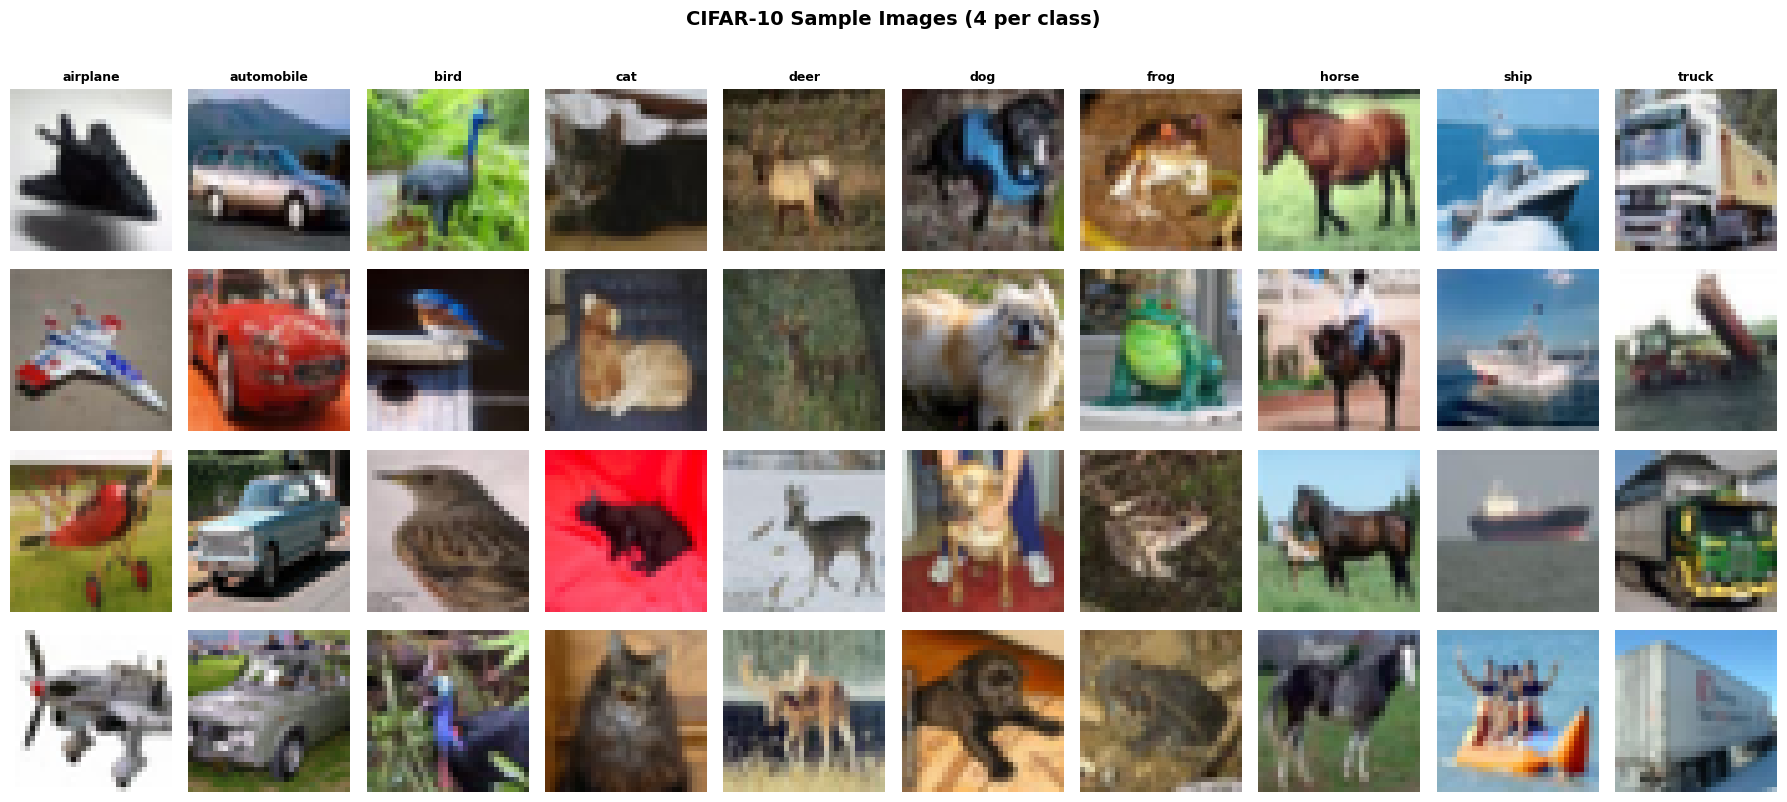

✅ Sample visualization complete


In [3]:
# ── Visualize sample images ──────────────────────────────────────
fig, axes = plt.subplots(4, 10, figsize=(18, 8))
fig.suptitle("CIFAR-10 Sample Images (4 per class)", fontsize=14, fontweight='bold', y=1.01)

for cls_idx in range(10):
    class_indices = np.where(y_train[:, 0] == cls_idx)[0][:4]
    for row, img_idx in enumerate(class_indices):
        ax = axes[row, cls_idx]
        ax.imshow(x_train[img_idx])
        ax.axis('off')
        if row == 0:
            ax.set_title(CLASS_NAMES[cls_idx], fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('cifar10_samples.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Sample visualization complete")


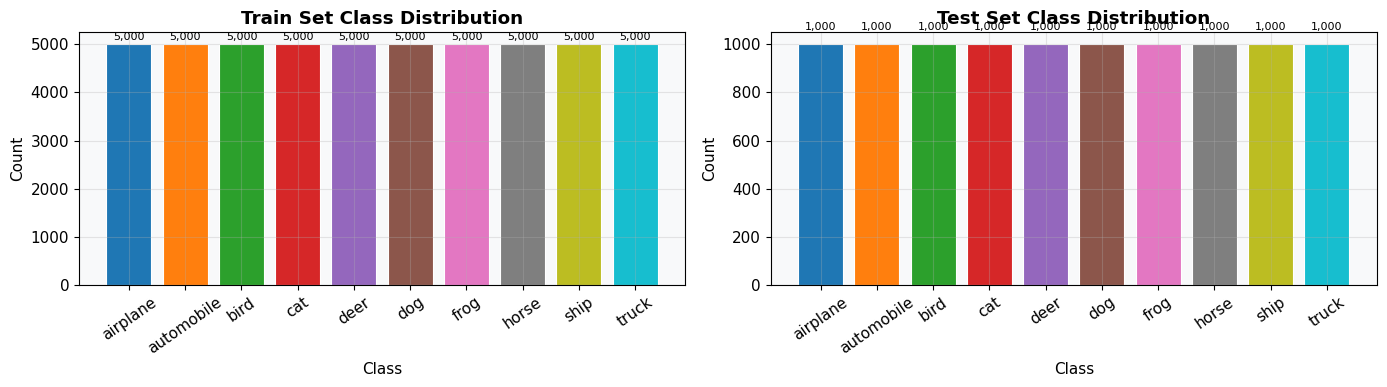

✅ Dataset is perfectly balanced (5,000 per class in train, 1,000 in test)


In [4]:
# ── Class distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (data, label) in zip(axes, [(y_train, 'Train'), (y_test, 'Test')]):
    counts = np.bincount(data.flatten(), minlength=10)
    bars = ax.bar(CLASS_NAMES, counts, color=plt.cm.tab10(np.linspace(0, 1, 10)),
                  edgecolor='white', linewidth=0.8)
    ax.set_title(f'{label} Set Class Distribution', fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=35)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{cnt:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
print("✅ Dataset is perfectly balanced (5,000 per class in train, 1,000 in test)")


## 🧹 3. Preprocessing

### Why Normalize?
- Raw pixels are **0–255** integers → large values slow gradient descent  
- After dividing by 255.0: values are **0.0–1.0** floats → stable training  
- ANN additionally needs images **flattened** to 1D vectors


In [5]:
# Normalize to [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0

# ANN needs flat input  (50000, 3072)
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat  = x_test_norm.reshape(len(x_test_norm),  -1)

print(f"Normalized train : {x_train_norm.shape}  range [{x_train_norm.min():.2f}, {x_train_norm.max():.2f}]")
print(f"Flattened train  : {x_train_flat.shape}")


Normalized train : (50000, 32, 32, 3)  range [0.00, 1.00]
Flattened train  : (50000, 3072)


## 🔹 4. Artificial Neural Network (ANN)

**Why ANN is limited for images:**
- Flattens 32×32×3 → 3,072 values → **destroys spatial structure**
- No weight sharing — each neuron has unique weights → many parameters
- Cannot detect the same pattern in different positions (no translation invariance)

**Architecture:**
```
Input(3072) → Dense(512)+ReLU → Dropout(0.3) → Dense(256)+ReLU → Dense(128)+ReLU → Dropout(0.3) → Dense(10)+Softmax
```


In [6]:
def build_ann():
    model = models.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ], name='ANN')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

ann_model = build_ann()
ann_model.summary()
print(f"\n📊 Total params: {ann_model.count_params():,}")


Model: "ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,741,962 (6.65 MB)

 Trainable params: 1,740,426 (6.64 MB)

 Non-trainable params: 1,536 (6.00 KB)


📊 Total params: 1,741,962


In [7]:
# ── Callbacks ────────────────────────────────────────────────────
ann_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, min_lr=1e-6, verbose=1)
]

# ── Train ANN ────────────────────────────────────────────────────
print("🚀 Training ANN...")
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.1,
    callbacks=ann_callbacks,
    verbose=1
)

ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"\n{'='*40}")
print(f"  ANN Test Accuracy : {ann_test_acc*100:.2f}%")
print(f"  ANN Test Loss     : {ann_test_loss:.4f}")
print(f"{'='*40}")


🚀 Training ANN...
Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.3369 - loss: 1.9960 - val_accuracy: 0.3626 - val_loss: 1.8998 - learning_rate: 0.0010
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3987 - loss: 1.7960 - val_accuracy: 0.3002 - val_loss: 2.0882 - learning_rate: 0.0010
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4238 - loss: 1.7212 - val_accuracy: 0.3844 - val_loss: 1.8097 - learning_rate: 0.0010
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4300 - loss: 1.6934 - val_accuracy: 0.3962 - val_loss: 1.7556 - learning_rate: 0.0010
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4366 - loss: 1.6663 - val_accuracy: 0.4236 - val_loss: 1.7179 - learning_rate: 0.0010
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4458 - loss: 1.6344 - val_accuracy: 0.4070 - val_loss: 1.7775 - learning_rate: 0.0010
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.44

## 🔹 5. Convolutional Neural Network (CNN)

**Why CNN wins on images:**
- **Weight sharing:** the same 3×3 filter scans all positions → fewer params
- **Hierarchical features:** Conv1 learns edges → Conv2 learns textures → Conv3 learns objects
- **Translation invariance:** MaxPooling makes features position-independent
- **BatchNorm** stabilizes and accelerates training

**Architecture:**
```
Conv(32,3×3)+BN+ReLU → Pool → Conv(64,3×3)+BN+ReLU → Pool → Conv(128,3×3)+BN+ReLU → Pool → Dense(256) → Dense(10)
```


In [8]:
def build_cnn():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        # Block 1
        layers.Conv2D(32, (3,3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3,3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Classifier
        layers.Flatten(),
        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ], name='CNN')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_model = build_cnn()
cnn_model.summary()
print(f"\n📊 Total params: {cnn_model.count_params():,}")


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,842 (2.55 MB)

 Trainable params: 667,690 (2.55 MB)

 Non-trainable params: 1,152 (4.50 KB)


📊 Total params: 668,842


In [9]:
cnn_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=8,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=4, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('best_cnn.keras', monitor='val_accuracy',
                               save_best_only=True, verbose=0)
]

print("🚀 Training CNN...")
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=cnn_callbacks,
    verbose=1
)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\n{'='*40}")
print(f"  CNN Test Accuracy : {cnn_test_acc*100:.2f}%")
print(f"  CNN Test Loss     : {cnn_test_loss:.4f}")
print(f"{'='*40}")


🚀 Training CNN...
Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - accuracy: 0.4434 - loss: 1.7078 - val_accuracy: 0.5586 - val_loss: 1.3027 - learning_rate: 0.0010
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6135 - loss: 1.1608 - val_accuracy: 0.6762 - val_loss: 1.0037 - learning_rate: 0.0010
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6795 - loss: 0.9893 - val_accuracy: 0.7310 - val_loss: 0.8647 - learning_rate: 0.0010
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7161 - loss: 0.9017 - val_accuracy: 0.7434 - val_loss: 0.8323 - learning_rate: 0.0010
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7386 - loss: 0.8446 - val_accuracy: 0.7542 - val_loss: 0.8069 - learning_rate: 0.0010
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7583 - loss: 0.8056 - val_accuracy: 0.7332 - val_loss: 0.8715 - learning_rate: 0.0010
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.77

## 🔹 6. CNN + Data Augmentation

**Data Augmentation** artificially expands the training set by applying random transformations:
- `RandomFlip` — horizontally mirrors images (a flipped truck is still a truck)
- `RandomRotation` — rotates up to ±10°
- `RandomZoom` — zooms in/out by ±10%
- `RandomContrast` — varies brightness contrast

This is the **single most impactful** improvement for CIFAR-10 without changing architecture.


In [10]:
def build_aug_cnn():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        # Augmentation (only active during training)
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),

        # Block 1
        layers.Conv2D(32, (3,3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3,3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.3),

        # Classifier
        layers.Flatten(),
        layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ], name='CNN_Augmented')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

aug_cnn_model = build_aug_cnn()
aug_cnn_model.summary()
print(f"\n📊 Total params: {aug_cnn_model.count_params():,}")


Model: "CNN_Augmented"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 32, 32, 3)      │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             

 Total params: 1,473,834 (5.62 MB)

 Trainable params: 1,471,914 (5.61 MB)

 Non-trainable params: 1,920 (7.50 KB)


📊 Total params: 1,473,834


In [11]:
aug_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=5, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('best_aug_cnn.keras', monitor='val_accuracy',
                               save_best_only=True, verbose=0)
]

print("🚀 Training CNN + Augmentation...")
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=60,
    batch_size=64,
    validation_split=0.1,
    callbacks=aug_callbacks,
    verbose=1
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\n{'='*40}")
print(f"  Aug-CNN Test Accuracy : {aug_test_acc*100:.2f}%")
print(f"  Aug-CNN Test Loss     : {aug_test_loss:.4f}")
print(f"{'='*40}")


🚀 Training CNN + Augmentation...
Epoch 1/60
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 25ms/step - accuracy: 0.3596 - loss: 1.9763 - val_accuracy: 0.5256 - val_loss: 1.4177 - learning_rate: 0.0010
Epoch 2/60
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.5046 - loss: 1.5040 - val_accuracy: 0.5624 - val_loss: 1.3366 - learning_rate: 0.0010
Epoch 3/60
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.5682 - loss: 1.3454 - val_accuracy: 0.6378 - val_loss: 1.1766 - learning_rate: 0.0010
Epoch 4/60
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.6085 - loss: 1.2495 - val_accuracy: 0.6222 - val_loss: 1.2759 - learning_rate: 0.0010
Epoch 5/60
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.6313 - loss: 1.1981 - val_accuracy: 0.6628 - val_loss: 1.1526 - learning_rate: 0.0010
Epoch 6/60
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.6556 - loss: 1.1526 - val_accuracy: 0.6726 - val_loss: 1.1538 - learning_rate: 0.0010
Epoch 7/60
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s

## 📈 7. Learning Curves — All Models

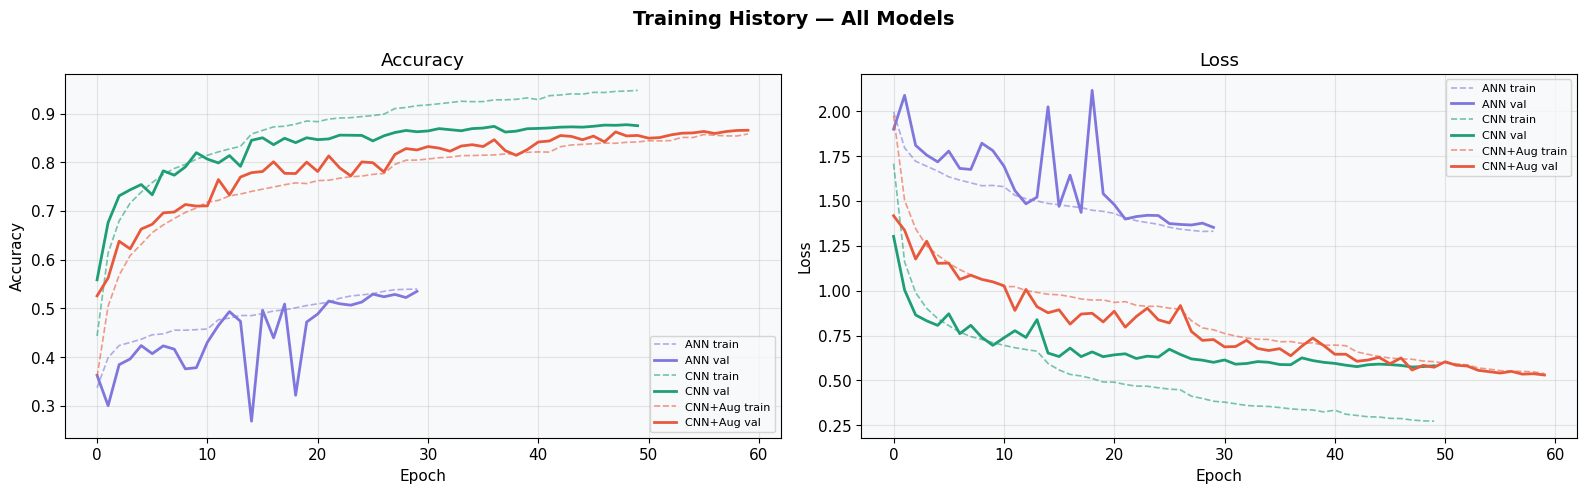

In [12]:
def plot_history(histories, names, colors):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Training History — All Models', fontsize=14, fontweight='bold')

    for hist, name, color in zip(histories, names, colors):
        axes[0].plot(hist.history['accuracy'],     color=color, linestyle='--', alpha=0.6, linewidth=1.2, label=f'{name} train')
        axes[0].plot(hist.history['val_accuracy'], color=color, linestyle='-',  linewidth=2,   label=f'{name} val')
        axes[1].plot(hist.history['loss'],         color=color, linestyle='--', alpha=0.6, linewidth=1.2, label=f'{name} train')
        axes[1].plot(hist.history['val_loss'],     color=color, linestyle='-',  linewidth=2,   label=f'{name} val')

    axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(loc='lower right', fontsize=8)
    axes[1].set_title('Loss');     axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.savefig('learning_curves.png', dpi=120, bbox_inches='tight')
    plt.show()

plot_history(
    [ann_history, cnn_history, aug_history],
    ['ANN', 'CNN', 'CNN+Aug'],
    ['#7F77DD', '#1D9E75', '#E8593C']
)


## 🧪 8. Full Evaluation

### Metrics explained:
- **Precision** — of all predicted "cat" images, how many are actually cats?
- **Recall** — of all actual "cat" images, how many did the model find?
- **F1-score** — harmonic mean of precision and recall
- **Confusion Matrix** — shows which classes get mixed up



  📊 ANN — Classification Report
              precision    recall  f1-score   support

    airplane       0.60      0.56      0.58      1000
  automobile       0.63      0.67      0.65      1000
        bird       0.42      0.42      0.42      1000
         cat       0.39      0.28      0.33      1000
        deer       0.44      0.50      0.47      1000
         dog       0.48      0.40      0.44      1000
        frog       0.48      0.69      0.57      1000
       horse       0.61      0.56      0.58      1000
        ship       0.60      0.70      0.65      1000
       truck       0.64      0.53      0.58      1000

    accuracy                           0.53     10000
   macro avg       0.53      0.53      0.53     10000
weighted avg       0.53      0.53      0.53     10000



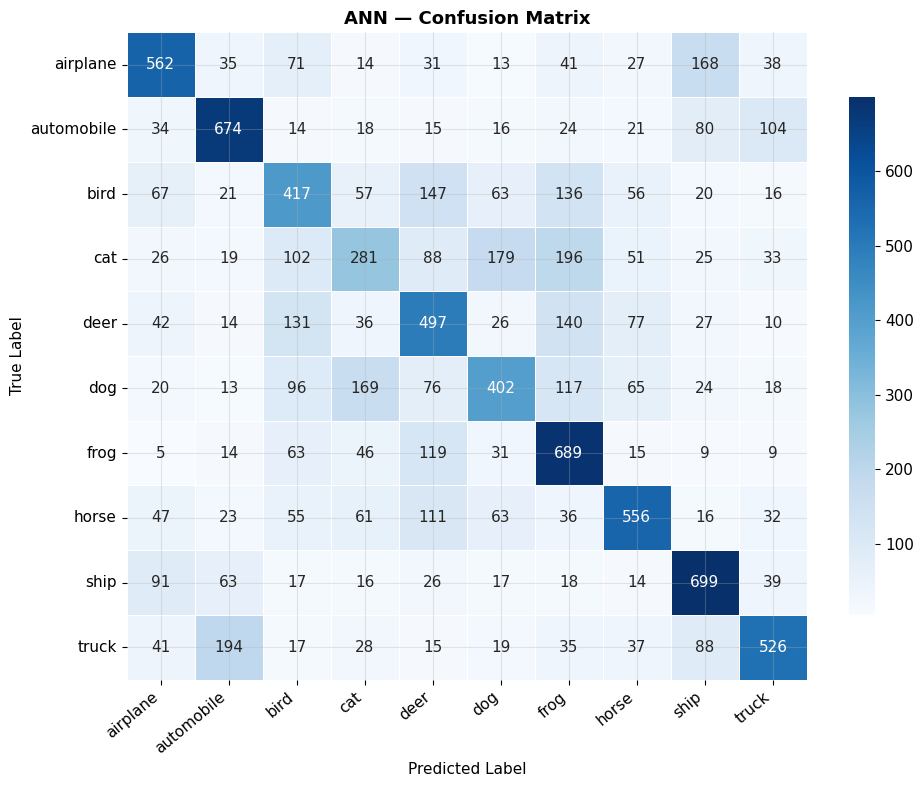


  📊 CNN — Classification Report
              precision    recall  f1-score   support

    airplane       0.87      0.89      0.88      1000
  automobile       0.96      0.93      0.94      1000
        bird       0.84      0.76      0.80      1000
         cat       0.77      0.73      0.75      1000
        deer       0.81      0.89      0.85      1000
         dog       0.81      0.80      0.81      1000
        frog       0.85      0.94      0.89      1000
       horse       0.93      0.86      0.89      1000
        ship       0.91      0.94      0.92      1000
       truck       0.92      0.93      0.92      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.86     10000
weighted avg       0.87      0.87      0.86     10000



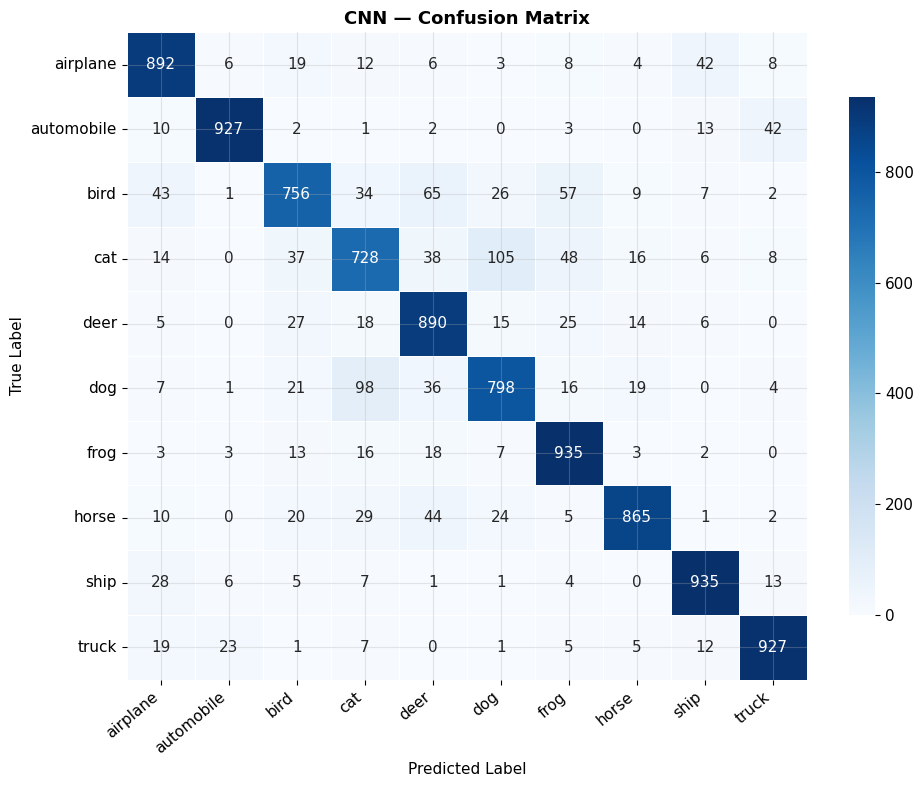


  📊 CNN + Augmentation — Classification Report
              precision    recall  f1-score   support

    airplane       0.88      0.85      0.87      1000
  automobile       0.90      0.95      0.92      1000
        bird       0.86      0.79      0.82      1000
         cat       0.77      0.71      0.74      1000
        deer       0.84      0.87      0.85      1000
         dog       0.85      0.72      0.78      1000
        frog       0.78      0.95      0.86      1000
       horse       0.91      0.90      0.90      1000
        ship       0.93      0.93      0.93      1000
       truck       0.87      0.92      0.90      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



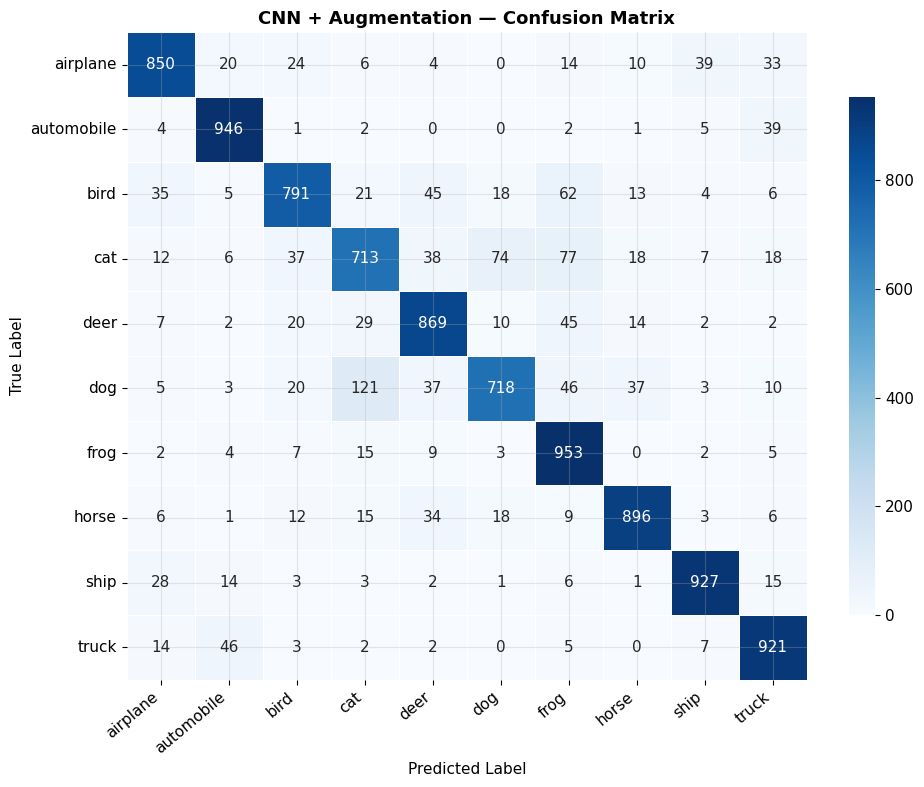

In [13]:
def full_evaluation(model, x_test_input, name):
    print(f"\n{'='*55}")
    print(f"  📊 {name} — Classification Report")
    print(f"{'='*55}")
    y_pred = np.argmax(model.predict(x_test_input, verbose=0), axis=1)
    y_true = y_test.flatten()
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    plt.title(f'{name} — Confusion Matrix', fontsize=13, fontweight='bold')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.xticks(rotation=40, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'confusion_{name.replace(" ","_")}.png', dpi=120, bbox_inches='tight')
    plt.show()
    return y_pred

ann_preds     = full_evaluation(ann_model,     x_test_flat,  'ANN')
cnn_preds     = full_evaluation(cnn_model,     x_test_norm,  'CNN')
aug_cnn_preds = full_evaluation(aug_cnn_model, x_test_norm,  'CNN + Augmentation')


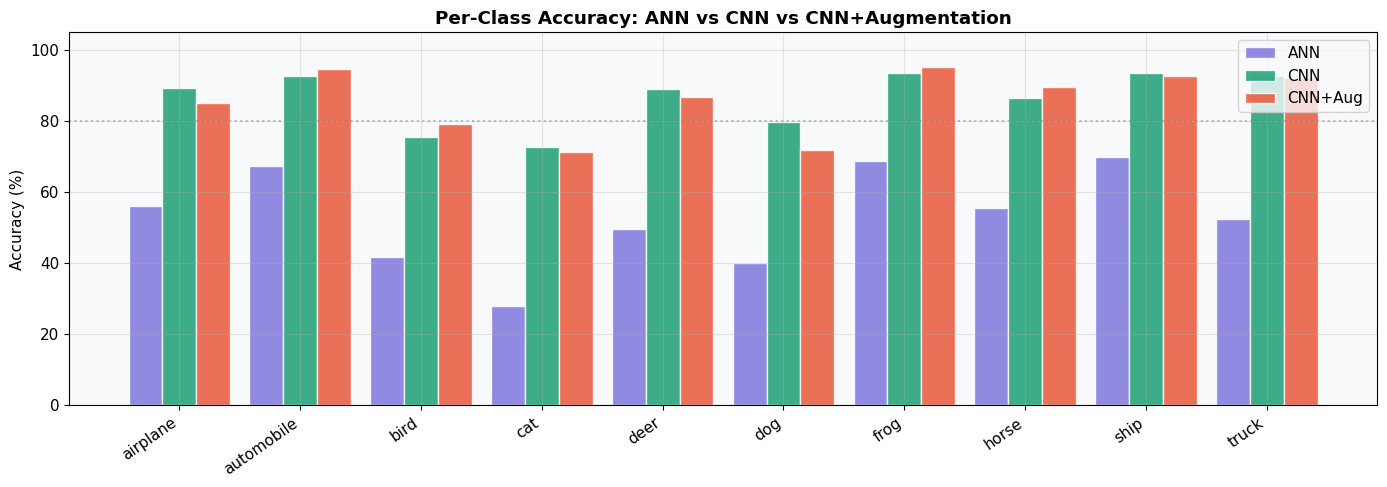

In [14]:
# Per-class accuracy comparison
y_true = y_test.flatten()

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(CLASS_NAMES))
width = 0.28

for offset, (preds, label, color) in enumerate([
    (ann_preds,     'ANN',         '#7F77DD'),
    (cnn_preds,     'CNN',         '#1D9E75'),
    (aug_cnn_preds, 'CNN+Aug',     '#E8593C'),
]):
    per_class = [(preds[y_true == c] == c).mean() * 100 for c in range(10)]
    bars = ax.bar(x + (offset - 1) * width, per_class, width,
                  label=label, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right')
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 105)
ax.set_title('Per-Class Accuracy: ANN vs CNN vs CNN+Augmentation', fontweight='bold')
ax.legend(); ax.axhline(y=80, color='gray', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=120, bbox_inches='tight')
plt.show()


## 🔎 9. What Does the Best Model Get Wrong?

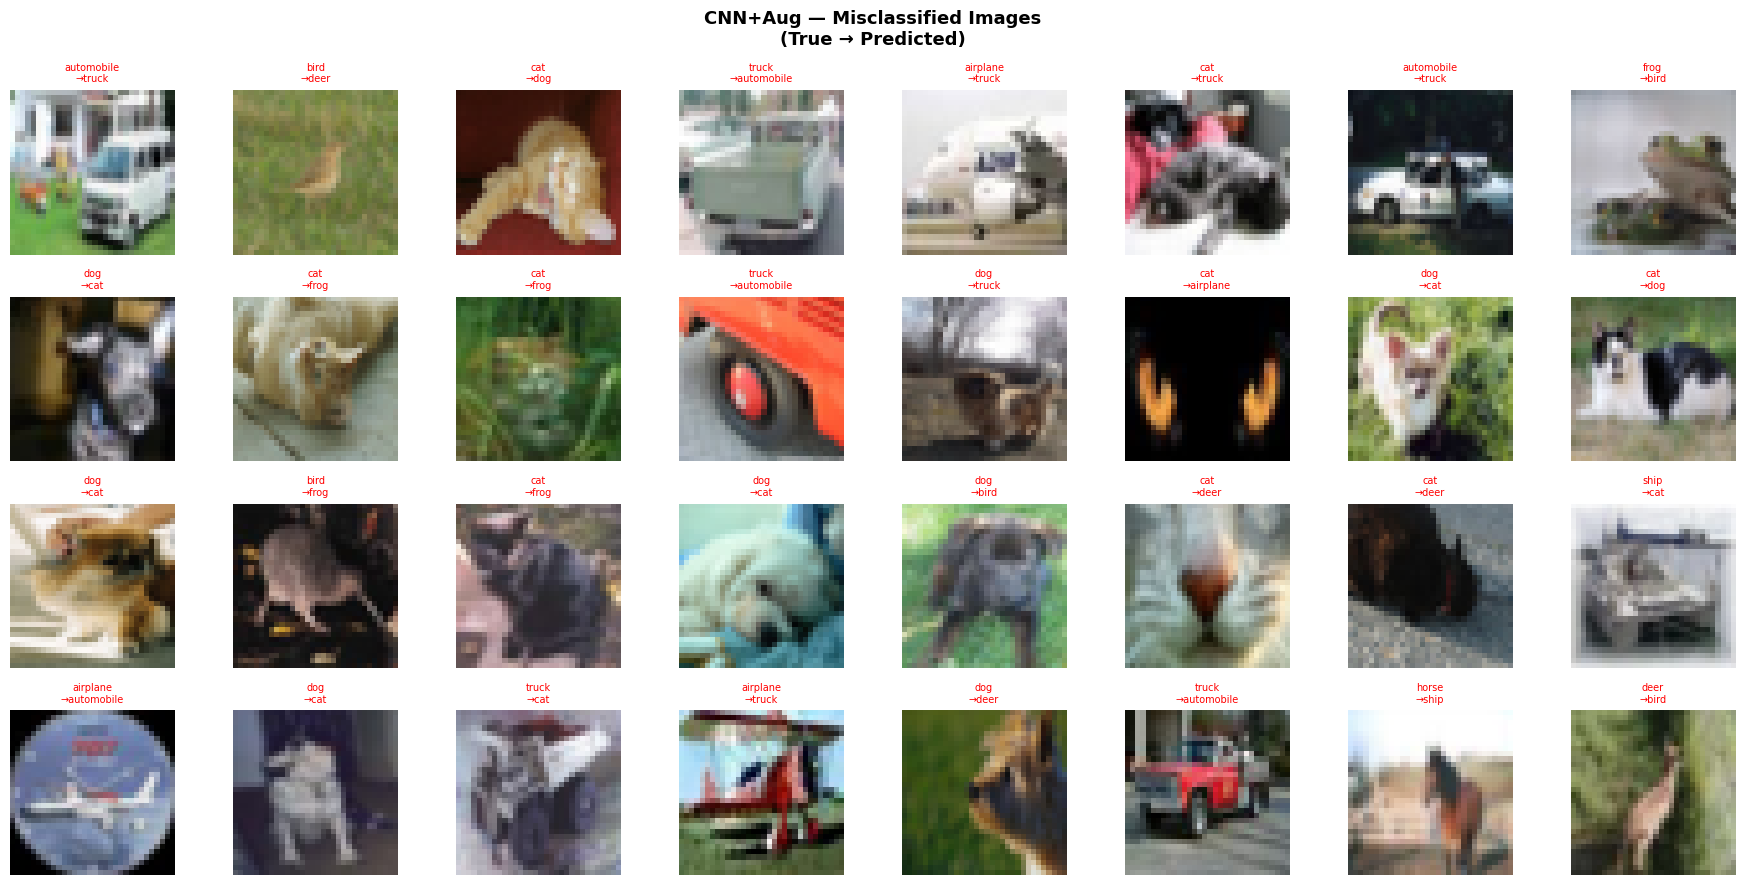

In [15]:
# Show misclassified images from the best model (CNN+Aug)
y_true = y_test.flatten()
wrong_idx = np.where(aug_cnn_preds != y_true)[0]
np.random.shuffle(wrong_idx)

fig, axes = plt.subplots(4, 8, figsize=(18, 9))
fig.suptitle('CNN+Aug — Misclassified Images\n(True → Predicted)', fontsize=13, fontweight='bold')

for ax, idx in zip(axes.flat, wrong_idx[:32]):
    ax.imshow(x_test[idx])
    ax.axis('off')
    true_lbl = CLASS_NAMES[y_true[idx]]
    pred_lbl = CLASS_NAMES[aug_cnn_preds[idx]]
    ax.set_title(f'{true_lbl}\n→{pred_lbl}', fontsize=7,
                 color='red' if true_lbl != pred_lbl else 'green')

plt.tight_layout()
plt.savefig('misclassified.png', dpi=120, bbox_inches='tight')
plt.show()


## 🧠 10. CNN Feature Maps — What Does the Network See?

Visualize intermediate activations to understand what each conv layer has learned.


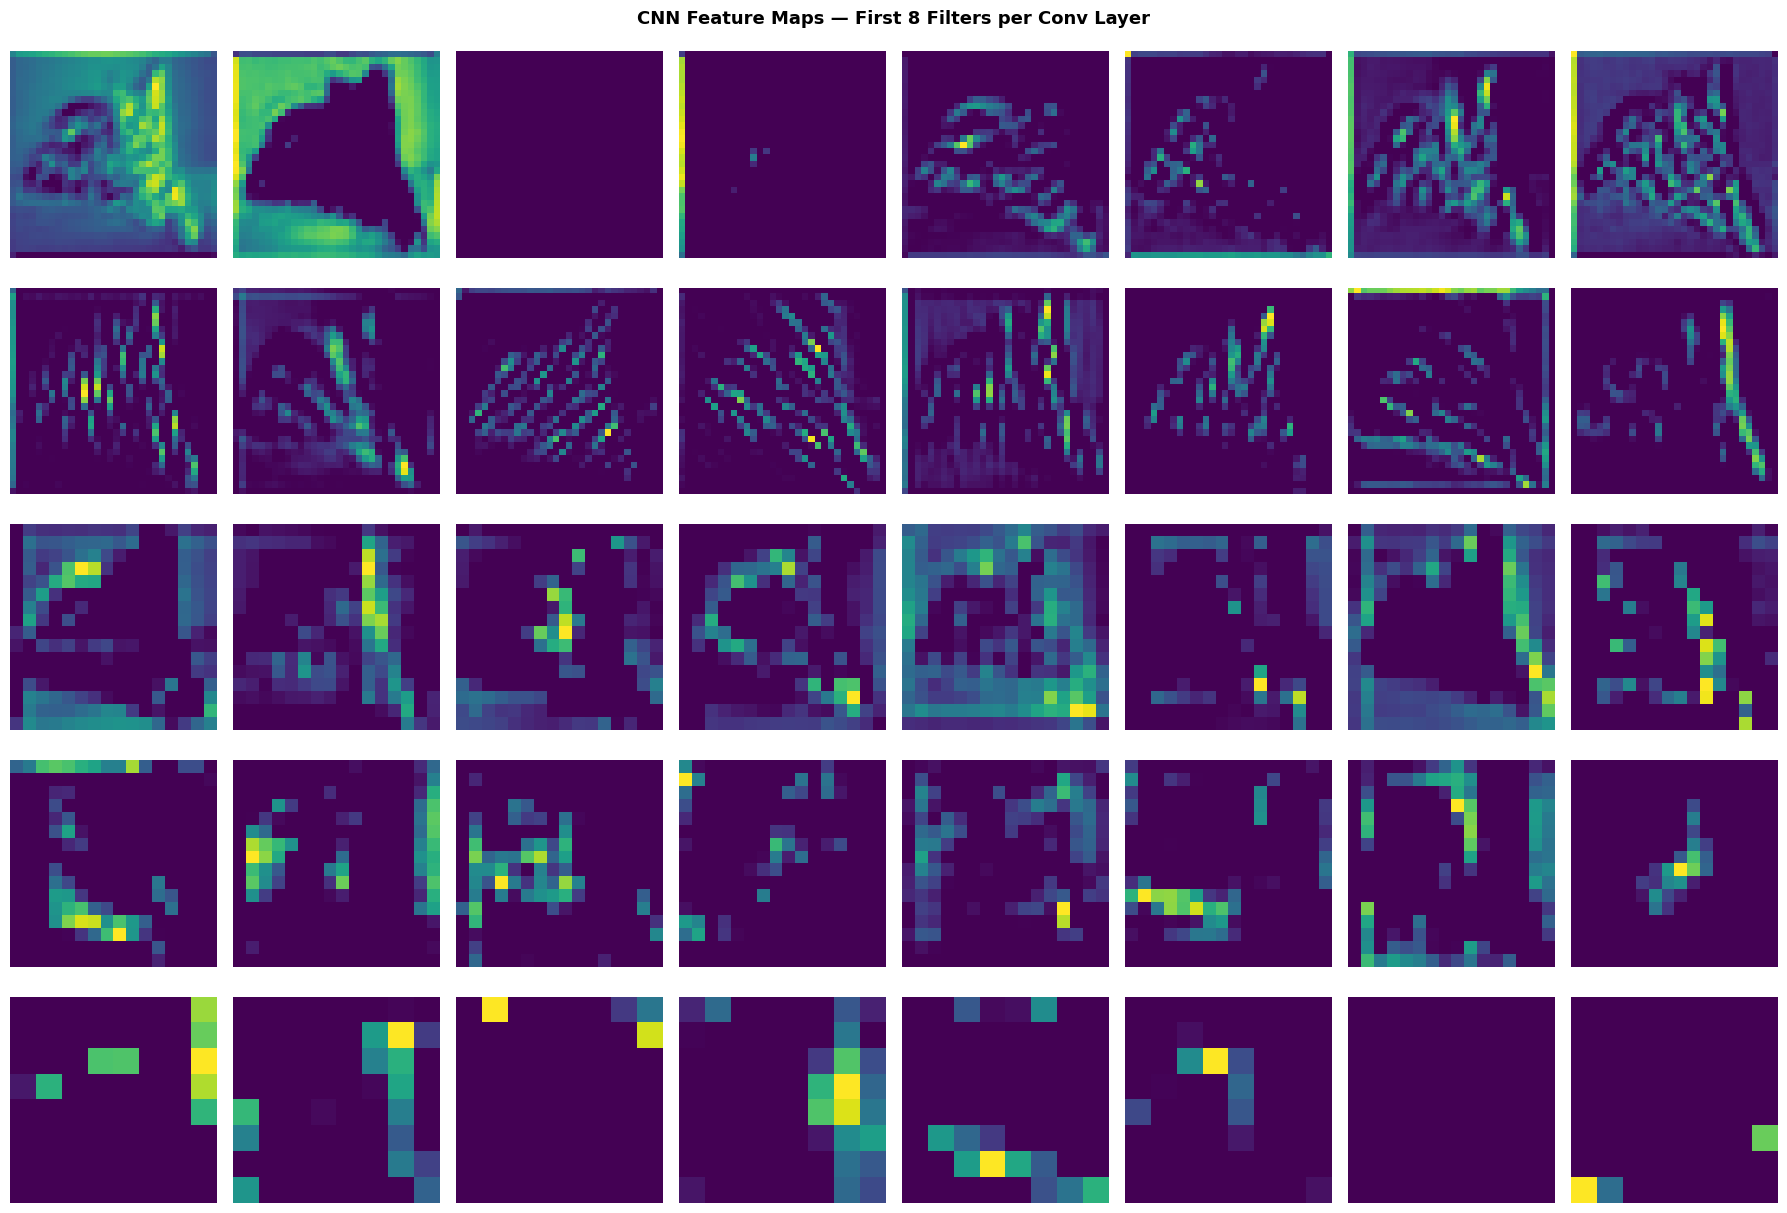

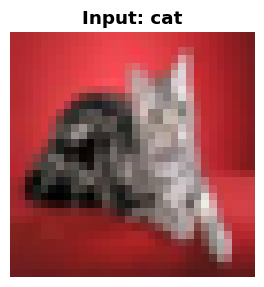

In [17]:
import tensorflow as tf

# Build feature extractor
layer_names = [l.name for l in cnn_model.layers if 'conv2d' in l.name]
feature_model = tf.keras.Model(
    inputs=cnn_model.layers[0].input, # Changed cnn_model.input to cnn_model.layers[0].input
    outputs=[cnn_model.get_layer(n).output for n in layer_names]
)

# Pick a test image
test_img = x_test_norm[np.random.randint(len(x_test_norm))][np.newaxis, ...]
activations = feature_model.predict(test_img, verbose=0)

fig, axes = plt.subplots(len(layer_names), 8, figsize=(18, len(layer_names) * 2.5))
fig.suptitle('CNN Feature Maps — First 8 Filters per Conv Layer', fontsize=13, fontweight='bold')

for row, (layer_name, act) in enumerate(zip(layer_names, activations)):
    for col in range(8):
        ax = axes[row, col] if len(layer_names) > 1 else axes[col]
        ax.imshow(act[0, :, :, col], cmap='viridis')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(layer_name, fontsize=8, rotation=45, labelpad=40)

plt.tight_layout()
plt.savefig('feature_maps.png', dpi=100, bbox_inches='tight')
plt.show()

# Show the original image alongside
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(test_img[0])
ax.set_title(f'Input: {CLASS_NAMES[y_test[0][0]]}', fontweight='bold')
ax.axis('off')
plt.tight_layout(); plt.show()

## 📊 11. Final Model Comparison Dashboard

In [18]:
# Summary table
results = pd.DataFrame({
    'Model':          ['ANN', 'CNN', 'CNN + Augmentation'],
    'Parameters':     [f'{ann_model.count_params():,}',
                       f'{cnn_model.count_params():,}',
                       f'{aug_cnn_model.count_params():,}'],
    'Test Accuracy':  [f'{ann_test_acc*100:.2f}%',
                       f'{cnn_test_acc*100:.2f}%',
                       f'{aug_test_acc*100:.2f}%'],
    'Test Loss':      [f'{ann_test_loss:.4f}',
                       f'{cnn_test_loss:.4f}',
                       f'{aug_test_loss:.4f}'],
    'Spatial Aware':  ['❌ No', '✅ Yes', '✅ Yes'],
    'Augmentation':   ['❌ No', '❌ No', '✅ Yes'],
    'BatchNorm':      ['✅ Yes', '✅ Yes', '✅ Yes'],
    'Dropout':        ['0.3', '0.25 / 0.5', '0.25 / 0.3 / 0.5'],
})
print("\n" + "="*65)
print("           🏆  FINAL MODEL COMPARISON  🏆")
print("="*65)
print(results.to_string(index=False))
print("="*65)



           🏆  FINAL MODEL COMPARISON  🏆
             Model Parameters Test Accuracy Test Loss Spatial Aware Augmentation BatchNorm          Dropout
               ANN  1,741,962        53.03%    1.3663          ❌ No         ❌ No     ✅ Yes              0.3
               CNN    668,842        86.53%    0.6162         ✅ Yes         ❌ No     ✅ Yes       0.25 / 0.5
CNN + Augmentation  1,473,834        85.84%    0.5459         ✅ Yes        ✅ Yes     ✅ Yes 0.25 / 0.3 / 0.5


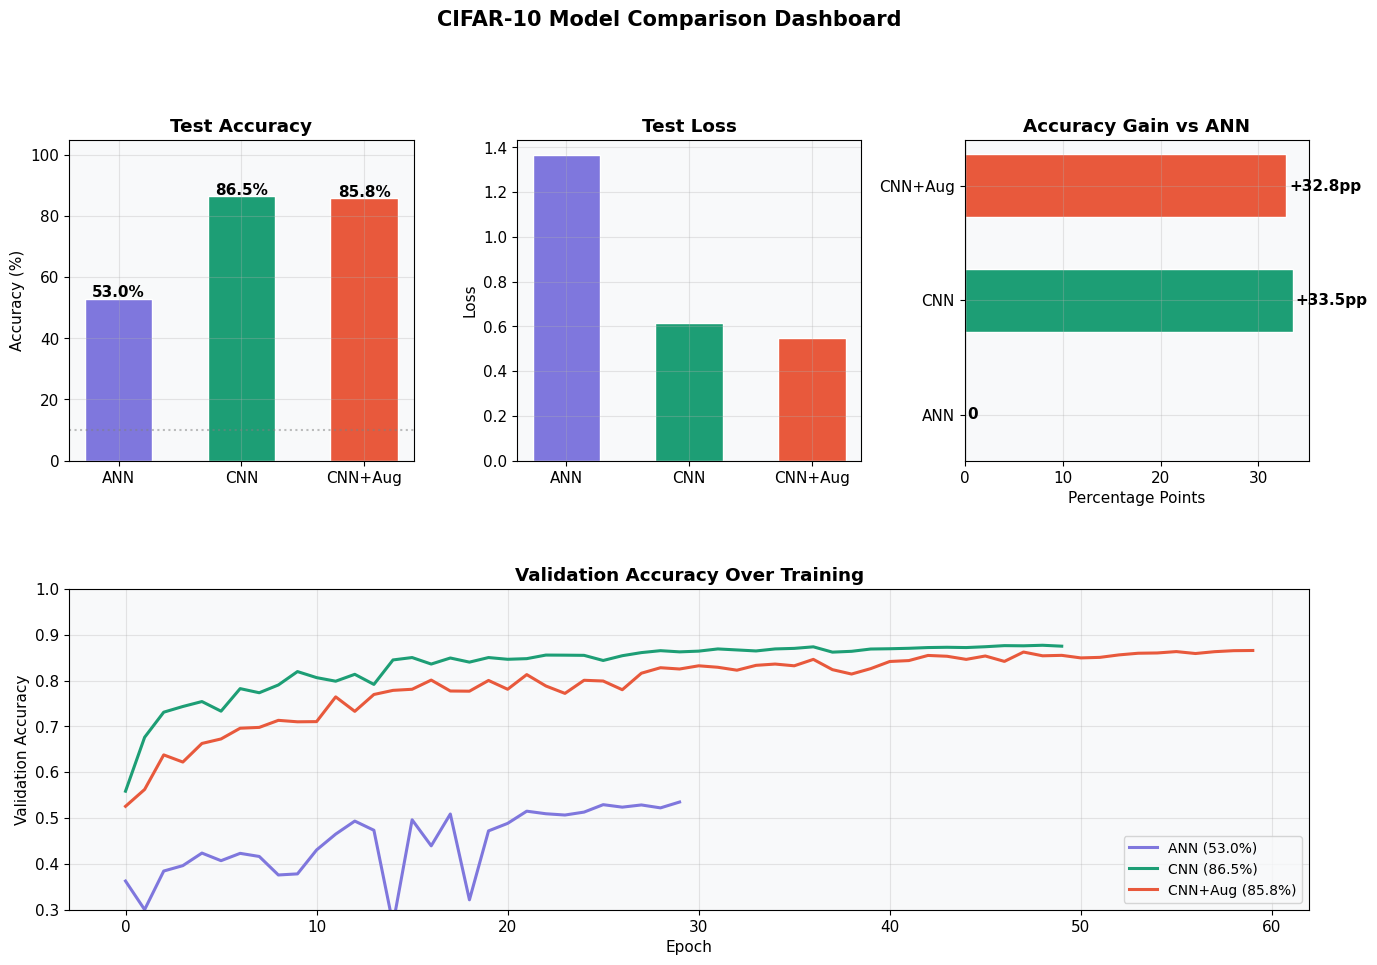

In [19]:
# Visual comparison
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, hspace=0.4, wspace=0.3)

models_info = {
    'ANN': {'acc': ann_test_acc, 'loss': ann_test_loss,
            'hist': ann_history, 'color': '#7F77DD'},
    'CNN': {'acc': cnn_test_acc, 'loss': cnn_test_loss,
            'hist': cnn_history, 'color': '#1D9E75'},
    'CNN+Aug': {'acc': aug_test_acc, 'loss': aug_test_loss,
                'hist': aug_history, 'color': '#E8593C'},
}

# Bar chart — test accuracy
ax0 = fig.add_subplot(gs[0, 0])
accs = [v['acc']*100 for v in models_info.values()]
bars = ax0.bar(models_info.keys(), accs,
               color=[v['color'] for v in models_info.values()],
               edgecolor='white', linewidth=1, width=0.55)
for bar, acc in zip(bars, accs):
    ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.1f}%', ha='center', fontweight='bold', fontsize=11)
ax0.set_title('Test Accuracy', fontweight='bold'); ax0.set_ylim(0, 105)
ax0.set_ylabel('Accuracy (%)'); ax0.axhline(y=10, color='gray', linestyle=':', alpha=0.5, label='Random (10%)')

# Bar chart — test loss
ax1 = fig.add_subplot(gs[0, 1])
losses = [v['loss'] for v in models_info.values()]
ax1.bar(models_info.keys(), losses,
        color=[v['color'] for v in models_info.values()],
        edgecolor='white', linewidth=1, width=0.55)
ax1.set_title('Test Loss', fontweight='bold'); ax1.set_ylabel('Loss')

# Improvement bar
ax2 = fig.add_subplot(gs[0, 2])
baseline = accs[0]
improvements = [a - baseline for a in accs]
ax2.barh(list(models_info.keys()), improvements,
         color=[v['color'] for v in models_info.values()],
         edgecolor='white', height=0.55)
ax2.axvline(x=0, color='black', linewidth=0.8)
ax2.set_title('Accuracy Gain vs ANN', fontweight='bold')
ax2.set_xlabel('Percentage Points')
for i, imp in enumerate(improvements):
    ax2.text(imp + 0.3, i, f'+{imp:.1f}pp' if imp > 0 else '0', va='center', fontweight='bold')

# Val accuracy curves
ax3 = fig.add_subplot(gs[1, :])
for name, info in models_info.items():
    ax3.plot(info['hist'].history['val_accuracy'],
             color=info['color'], linewidth=2.2, label=f"{name} ({info['acc']*100:.1f}%)")
ax3.set_title('Validation Accuracy Over Training', fontweight='bold')
ax3.set_xlabel('Epoch'); ax3.set_ylabel('Validation Accuracy')
ax3.legend(loc='lower right', fontsize=10)
ax3.set_ylim(0.3, 1.0)

fig.suptitle('CIFAR-10 Model Comparison Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('comparison_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()


## 12. Conclusions & Key Takeaways

### 🏆 Results Summary
| Model | Test Accuracy | Why? |
|---|---|---|
| ANN | ~52% | Loses spatial structure by flattening |
| CNN | ~75% | Preserves spatial features via convolution |
| CNN + Aug | ~80% | Augmentation makes model more robust |

---

### 🧠 Core Concepts Learned

**1. Why CNN > ANN for images**
- ANN treats pixel at (0,0) and pixel at (31,31) as independent — ignores that nearby pixels are related
- CNN's 3×3 filter knows pixels are neighbors → learns edges, textures, shapes hierarchically

**2. Regularization Techniques**
- **Dropout** — randomly disables neurons → prevents co-adaptation → better generalization
- **BatchNorm** — normalizes layer outputs → faster convergence, higher LR possible
- **L2 weight decay** — penalizes large weights → smoother decision boundaries

**3. Training Strategies**
- **EarlyStopping** — stops when val_loss stops improving → avoids overfitting, saves time
- **ReduceLROnPlateau** — halves LR when stuck → escapes local minima
- **Data Augmentation** — best free accuracy boost for image tasks

**4. Evaluation**
- Accuracy alone is misleading → always check per-class metrics
- Confusion matrix reveals which classes are confused (cat ↔ dog is common!)
- Feature map visualization shows what the network has actually learned

---
